### Import all packages need in the cell below

In [1]:
using Pkg
using JuMP, Ipopt, HiGHS
using Plots
Pkg.add("GLPK")
Pkg.add("JuMP")


   Resolving package versions...
     Project No packages added to or removed from `C:\Users\leite\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\leite\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\leite\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\leite\.julia\environments\v1.12\Manifest.toml`


# Problem Statement
1 Topico 1
A small engineering consulting firmh as 3 senior designers available to work on the firm’s 4 current project sover the next 2weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager’s scoring (0=nil to 100=perfect)of the capability of each designer to contribute to each project,along with his estimate of the hours that each project will require.
Project
Designer 1    2  3   4
1        90  80  10  50
2        60  70  50  65
3        70  40  80  85
Required 70  50  85  35

(a)Formulate an allocation LP to choose an optimal work as signment.

In [2]:
# DADOS DO PROBLEMA
# Número de designers e projetos
num_designers = 3
num_projects = 4

# Pontuações de capacidade
# score[i,j] = pontuação do designer i no projeto j
score = [
    90  80  10  50;
    60  70  50  65;
    70  40  80  85
]

# Horas requeridas por cada projeto
required_hours = [70, 50, 85, 35]

# Horas disponíveis por designer
available_hours = [80, 80, 80]

# CRIAÇÃO DO MODELO
model = Model(HiGHS.Optimizer)

# VARIÁVEIS DE DECISÃO
# x[i,j] = número de horas que o designer i
# dedica ao projeto j
@variable(model, x[1:num_designers, 1:num_projects] >= 0)


# FUNÇÃO OBJETIVO
==
# Maximizar a pontuação total de contribuição:
# soma de (pontuação × horas alocadas)

@objective(model, Max,
    sum(score[i,j] * x[i,j] for i in 1:num_designers, j in 1:num_projects)
)


# RESTRIÇÕES DE DISPONIBILIDADE DOS DESIGNERS

# Cada designer pode trabalhar no máximo 80 horas

@constraint(model, [i in 1:num_designers],
    sum(x[i,j] for j in 1:num_projects) <= available_hours[i]
)


# RESTRIÇÕES DE DEMANDA DOS PROJETOS
# Cada projeto deve receber exatamente o número
# de horas exigido
@constraint(model, [j in 1:num_projects],
    sum(x[i,j] for i in 1:num_designers) == required_hours[j]
)

# RESOLVER O MODELO

optimize!(model)

# RESULTADOS
println("Status da solução: ", termination_status(model))
println("Pontuação total máxima = ", objective_value(model))
println()

println("Horas alocadas (designer x projeto):")
for i in 1:num_designers
    for j in 1:num_projects
        println("Designer ", i, " -> Projeto ", j, ": ", value(x[i,j]), " horas")
    end
end

println()
println("Resumo por designer:")
for i in 1:num_designers
    println("Designer ", i, ": ", sum(value(x[i,j]) for j in 1:num_projects), " horas")
end

println()
println("Resumo por projeto:")
for j in 1:num_projects
    println("Projeto ", j, ": ", sum(value(x[i,j]) for i in 1:num_designers), " horas")
end

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 7 rows; 12 cols; 24 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+01, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 8e+01]
Presolving model
7 rows, 12 cols, 24 nonzeros  0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
7 rows, 12 cols, 24 nonzeros  0s
Presolve reductions: rows 7(-0); columns 12(-0); nonzeros 24(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.4995459328e+02 Ph1: 7(24); Du: 12(749.955) 0.0s
          7     1.8825000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.8825000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time 

1.2
Prove the following results. Hint: Use the definition of convex functions,
the first and second order characterizations.
(a) Univariate functions:
• Exponential function: eax is convex for any a over R
• Power function: xa is convex for a ≥ 1 or a ≤ 0 over R+ (nonne
gative reals)
• Power function: xa is concave for 0 ≤ a ≤ 1 over R+
• Logarithmic function: logx is concave over R++
(b) Affine function: aTx +b is both convex and concave
(c) Quadratic function: 1
2
xTQx + bTx + c is convex provided that Q ⪰ 0
(positive semidefinite)
(d) Least squares loss: ∥y − Ax∥2
2 is always convex (since ATA is always
positive semidefinite)

(a) Univariate functions: • Exponential function: eax is convex for any a over R

In [3]:
using JuMP, HiGHS, Ipopt
using GLPK
using Plots

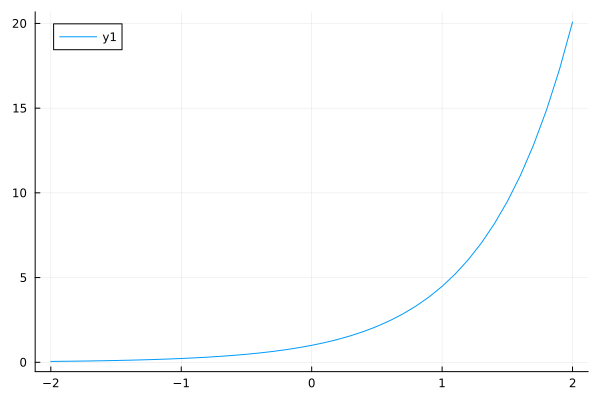

In [4]:
# Criar modelo (não é essencial pro gráfico, mas incluído)
model = Model(GLPK.Optimizer)

# Parâmetro da função
a = 1.5

# Criar valores de x
x_vals = -2:0.1:2

# Calcular f(x) = e^(a*x)
y_vals = [exp(a*x) for x in x_vals]

# Plotar
plot(x_vals, y_vals,
    xlabel = "x",
    ylabel = "f(x) = e^(ax)",
    title = "Função Exponencial",
    label = "e^($a x)",
    linewidth = 2
)
display(plot(x_vals, y_vals))

(a) Univariate functions: • Power function: xa is convex for a ≥ 1 or a ≤ 0 over R+ (nonne
gative reals)

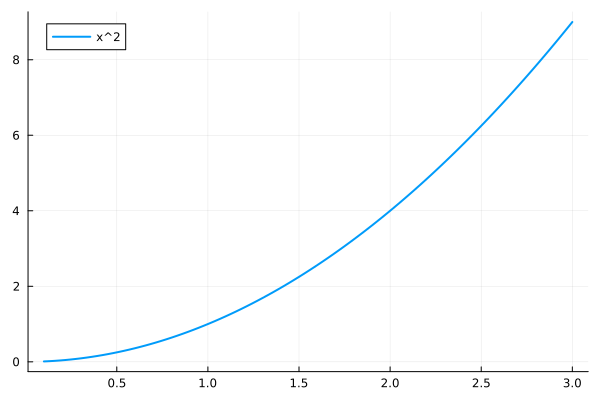

In [5]:
function plot_potencia(a)
    x = range(0.1, 3, length=100)
    y = [xi^a for xi in x]

    plot(x, y, label="x^$a", linewidth=2)
end

plot_potencia(2)   # convexa
#plot_potencia(0.5) # côncava

(a) Univariate functions: • Power function: xa is concave for 0 ≤ a ≤ 1 over R+


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        1

Total number of variables............................:        1
                     variables with only lower bounds:        1
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality c

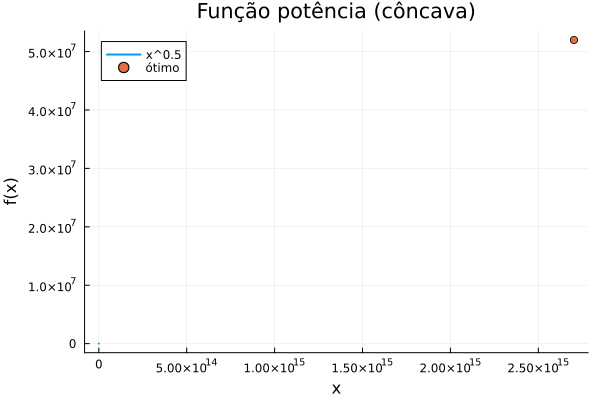

In [7]:
function potencia_concava_plot(a)

    # -------- PARTE 1: OTIMIZAÇÃO --------
    model = Model(Ipopt.Optimizer)

    @variable(model, x >= 0.1)

    @NLobjective(model, Max, x^a)

    optimize!(model)

    x_opt = value(x)
    f_opt = objective_value(model)

    println("x ótimo = ", x_opt)
    println("valor ótimo = ", f_opt)


    # -------- PARTE 2: PLOT --------
    x_vals = range(0.1, 3, length=100)
    y_vals = [xi^a for xi in x_vals]

    p = plot(x_vals, y_vals,
        label = "x^$a",
        linewidth = 2,
        title = "Função potência (côncava)",
        xlabel = "x",
        ylabel = "f(x)"
    )

    # ponto ótimo no gráfico
    scatter!(p, [x_opt], [f_opt], label="ótimo")

    display(p)  
end

potencia_concava_plot(0.5)

LOGATIMO

In [8]:
using JuMP
using Ipopt
using Plots

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        1

Total number of variables............................:        1
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        1
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -2.2072750e+00 0.00e+00 9.09e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

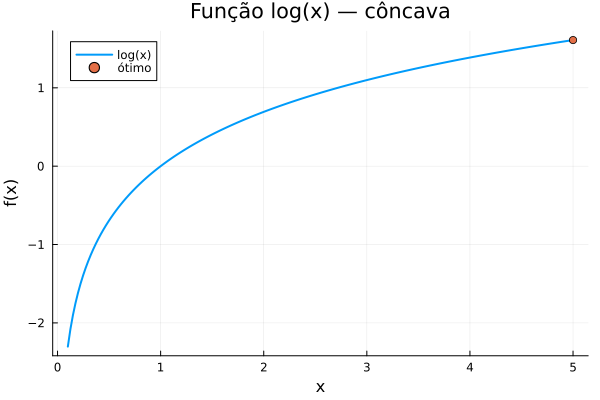

In [9]:

function log_concava_plot()

    # -------- PARTE 1: OTIMIZAÇÃO --------
    model = Model(Ipopt.Optimizer)

    @variable(model, 0.1 <= x <= 5)


    @NLobjective(model, Max, log(x))

    optimize!(model)

    x_opt = value(x)
    f_opt = objective_value(model)

    println("x ótimo = ", x_opt)
    println("valor ótimo = ", f_opt)

    # -------- PARTE 2: GRÁFICO --------
    x_vals = range(0.1, 5, length=200)
    y_vals = [log(xi) for xi in x_vals]

    p = plot(x_vals, y_vals,
        label = "log(x)",
        linewidth = 2,
        title = "Função log(x) — côncava",
        xlabel = "x",
        ylabel = "f(x)"
    )

    # ponto ótimo
    scatter!(p, [x_opt], [f_opt], label="ótimo")

    display(p)
end

log_concava_plot()